In [1]:
import sys
!{sys.executable} -m pip install fredapi yfinance alpha_vantage


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip


# Macro Data

In [2]:
from fredapi import Fred
import pandas as pd

fred = Fred(api_key='b29fa8db713c7d9498fc161a88fb77ac')

#UNRATE: unemployment rate
#CPIAUCSL: consumer price index (inflaton)
#FEDFUNDS: effective federal funds rate (interest rates)
#GDPC1: Real Gross Domestic Product
#T10Y2Y: Yield Curve (recession indicator)
#TEDRATE: TED Spread (interbank credit risk)
#VIXLS: CBOE (market fear)
#BAMLH0A0HYM2: Bank of America's US High Yield Index (Credit risk)

indexes = ['UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'GDPC1', 'T10Y2Y', 'TEDRATE', 'VIXCLS', 'BAMLH0A0HYM2']

data = {}
for index in indexes:
    data[index] = fred.get_series(index)

df_macro = pd.DataFrame(data)
df_macro.index.name = 'Date'
df_macro = df_macro.loc['2000-01-01':]

In [3]:
df_macro.head()

,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2
Date,,,,,,,,
2000-01-01,4.0,169.3,5.45,13878.147,NaN,NaN,NaN,NaN
2000-01-03,NaN,NaN,NaN,NaN,0.20,NaN,24.21,4.68
2000-01-04,NaN,NaN,NaN,NaN,0.19,0.77,27.01,4.81
2000-01-05,NaN,NaN,NaN,NaN,0.24,0.75,26.41,4.77
2000-01-06,NaN,NaN,NaN,NaN,0.22,0.78,25.73,4.82


# Sector Specific

In [4]:
import yfinance as yf

#ticker symbols
# CL=F: crude oil futures
# GC=F: gold futures 
# XLE: energy select sector (correlation with oil)
# XLK: technology select sector
# XLF: financial sector (rate sensistive)
# GSPC: S and P 500 Index
# TNX: 10 year treasuring yield

tickers = ['CL=F', 'GC=F', 'XLE', 'XLK', 'XLF', '^GSPC', '^TNX']
df_sector = yf.download(tickers, start="2000-01-01", interval="1d", auto_adjust=True)['Close']

[*********************100%***********************]  7 of 7 completed


In [5]:
df_sector.head()

Ticker,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX
Date,,,,,,,
2000-01-03,NaN,NaN,6.699403,11.147916,20.652033,1455.219971,6.548
2000-01-04,NaN,NaN,6.573298,10.660578,19.604300,1399.420044,6.485
2000-01-05,NaN,NaN,6.746694,10.576814,19.313259,1402.109985,6.599
2000-01-06,NaN,NaN,7.006788,11.041310,18.672974,1403.449951,6.549
2000-01-07,NaN,NaN,7.081667,11.224062,18.998938,1441.469971,6.504


# Global Interdependencies

In [6]:
from alpha_vantage.foreignexchange import ForeignExchange 
import time

fe = ForeignExchange(key='DCCXHV23S5TTXJT1', output_format='pandas')

#exchange rates for US dollar against other
currencies = ['EUR', 'KRW', 'CAD']
fx_data = []

for currency in currencies:
    try:
        data, _ = fe.get_currency_exchange_daily(from_symbol='USD', to_symbol=currency)
        
        series = data['4. close'].rename(f'USD_{currency}')
        fx_data.append(series)
        
        # Pause to respect free tier API limits (5 calls per minute)
        time.sleep(3) 
        
    except Exception as e:
        print(f"Error fetching {currency}: {e}")

df_fx = pd.concat(fx_data, axis=1)

In [7]:
df_fx.head()

,USD_EUR,USD_KRW,USD_CAD
date,,,
2026-02-11,0.8422,1446.02,1.3574
2026-02-10,0.8406,1456.47,1.3550
2026-02-09,0.8392,1457.53,1.3554
2026-02-06,0.8462,1463.35,1.3679
2026-02-05,0.8490,1471.62,1.3710


# Data Cleaning + EDA

In [8]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

In [9]:
df_main = df_sector.join(df_macro, how='outer').join(df_fx, how='outer')
df_main.sort_index(inplace=True)

# forward fill bc market uses that monthly or weekly number
df_main.fillna(method='ffill', inplace=True)
df_main.dropna(inplace=True)
df_main

/var/folders/n9/hrwgbvx936vf2n8y560vb_lc0000gn/T/ipykernel_42318/2310242047.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_main.fillna(method='ffill', inplace=True)


,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,GDPC1,T10Y2Y,TEDRATE,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-09-25,64.980003,3736.899902,45.189789,53.283772,138.789490,6604.720215,4.172,4.4,324.368,4.22,24026.834,0.54,0.09,16.74,2.76,0.8570,1409.00,1.3940
2025-09-26,65.720001,3775.300049,45.606236,53.672413,139.208847,6643.700195,4.187,4.4,324.368,4.22,24026.834,0.57,0.09,15.29,2.75,0.8545,1409.45,1.3942
2025-09-29,63.450001,3820.899902,44.768379,53.941471,139.952713,6661.209961,4.141,4.4,324.368,4.22,24026.834,0.52,0.09,16.12,2.74,0.8527,1399.88,1.3911
2025-09-30,62.369999,3840.800049,44.292435,53.682377,140.716553,6688.459961,4.148,4.4,324.368,4.22,24026.834,0.56,0.09,16.28,2.80,0.8522,1403.85,1.3920
2025-10-01,61.779999,3867.500000,44.292435,53.204048,142.094467,6711.200195,4.106,4.4,324.368,4.09,24026.834,0.57,0.09,16.29,2.81,0.8524,1402.69,1.3934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-05,63.290001,4861.399902,52.209999,53.290001,135.630005,6798.399902,4.210,4.3,326.030,3.64,24026.834,0.74,0.09,21.77,2.97,0.8490,1471.62,1.3710
2026-02-06,63.549999,4951.200195,53.250000,54.259998,141.130005,6932.299805,4.206,4.3,326.030,3.64,24026.834,0.72,0.09,17.76,2.87,0.8462,1463.35,1.3679
2026-02-09,64.360001,5050.899902,53.639999,53.939999,143.350006,6964.819824,4.198,4.3,326.030,3.64,24026.834,0.74,0.09,17.36,2.84,0.8392,1457.53,1.3554
2026-02-10,63.959999,5003.799805,53.580002,53.549999,142.550003,6941.810059,4.147,4.3,326.030,3.64,24026.834,0.71,0.09,17.79,2.86,0.8406,1456.47,1.3550


In [10]:
df_main.drop(columns=['GDPC1'], inplace=True)
df_main.drop(columns=['TEDRATE'], inplace=True)

In [11]:
# need to make sure PCMCI picks up on actual dependencies, and not just a general growth

df_transform = pd.DataFrame(index=df_main.index)





#1. rates and spreads: these variables are percentages or indices so we care more about the change 
rate_vars = ['UNRATE', 'FEDFUNDS', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'TEDRATE']

#2. asset prices: grows exponentially and would cause heteroscedasticity so use log 
price_vars = [col for col in df_main.columns if col not in rate_vars]

for col in df_main.columns:
    if col in rate_vars:
        # simple difference
        df_transform[col] = df_main[col].diff()
    else:
        #log of returns (ln(price today / price yesterday))
        df_transform[col] = np.log(df_main[col] / df_main[col].shift(1))

df_transform.dropna(inplace=True)

In [12]:
df_transform.head()

,CL=F,GC=F,XLE,XLF,XLK,^GSPC,^TNX,UNRATE,CPIAUCSL,FEDFUNDS,T10Y2Y,VIXCLS,BAMLH0A0HYM2,USD_EUR,USD_KRW,USD_CAD
2025-09-26,0.011324,0.010223,0.009173,0.007267,0.003017,0.005884,0.003589,0.0,0.0,0.00,0.03,-1.45,-0.01,-0.002921,0.000319,0.000143
2025-09-29,-0.035151,0.012006,-0.018542,0.005000,0.005329,0.002632,-0.011047,0.0,0.0,0.00,-0.05,0.83,-0.01,-0.002109,-0.006813,-0.002226
2025-09-30,-0.017168,0.005195,-0.010688,-0.004815,0.005443,0.004083,0.001689,0.0,0.0,0.00,0.04,0.16,0.06,-0.000587,0.002832,0.000647
2025-10-01,-0.009505,0.006928,0.000000,-0.008950,0.009744,0.003394,-0.010177,0.0,0.0,-0.13,0.01,0.01,0.01,0.000235,-0.000827,0.001005
2025-10-02,-0.021267,-0.007214,-0.010125,-0.000749,0.005396,0.000618,-0.004393,0.0,0.0,0.00,-0.02,0.34,0.00,0.001172,0.002257,0.002294


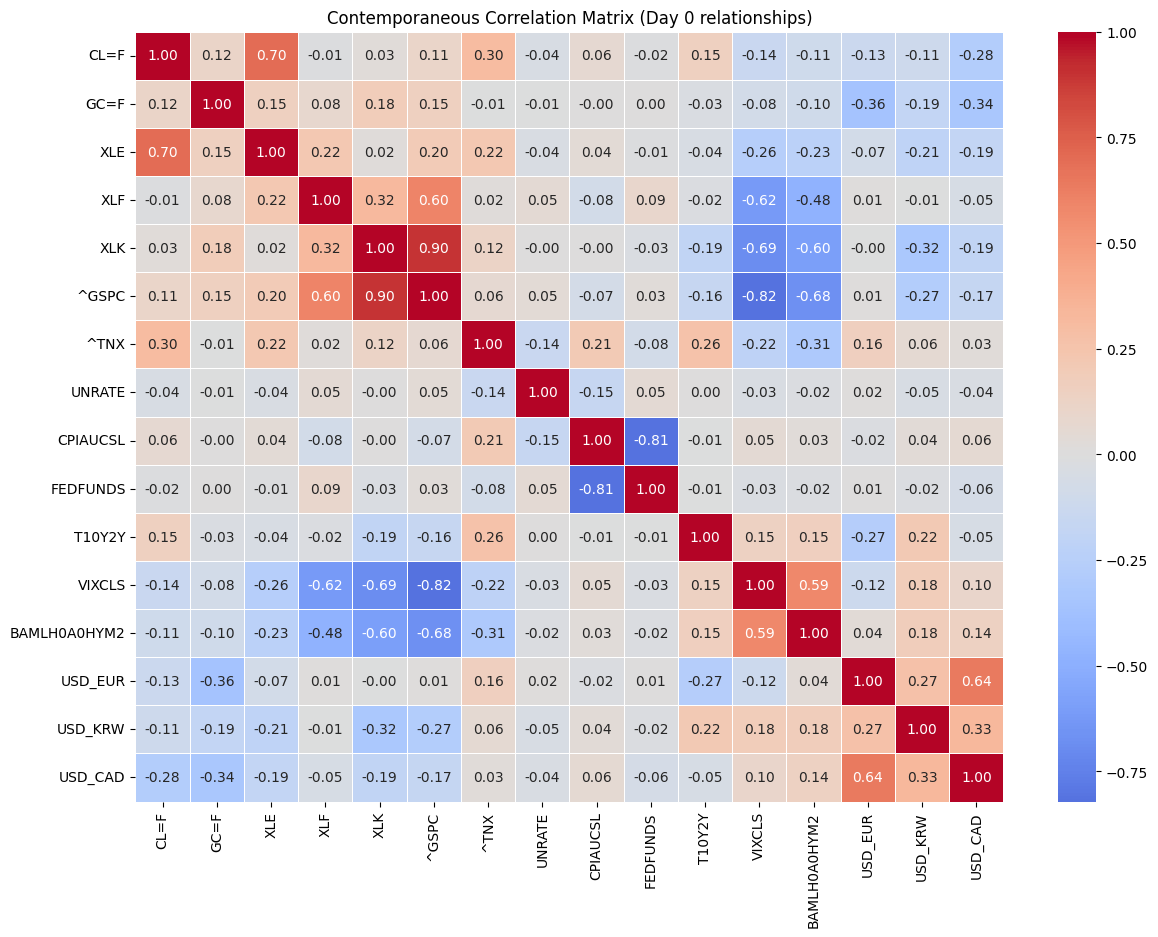

In [13]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    df_transform.corr(), 
    annot=True,       # Show the numbers
    cmap='coolwarm',  # Blue (Neg) to Red (Pos)
    center=0,         # Set 0 as the middle (white)
    fmt=".2f",        # 2 decimal places
    linewidths=0.5
)
plt.title("Contemporaneous Correlation Matrix (Day 0 relationships)")
plt.show()

# Analysis

In [14]:
# Install Tigramite and dependencies
!pip install Cython
!pip install tigramite
!pip install pandas numpy matplotlib seaborn
!pip install tigramite matplotlib pandas numpy

In [15]:
import sys

# 1. Install specifically for the active kernel
%pip install tigramite

# 2. Add the current environment's path to sys.path manually (emergency bypass)
if sys.prefix not in sys.path:
    sys.path.append(f"{sys.prefix}/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages")

# 3. Test the import immediately
try:
    import tigramite
    print("Success! Tigramite is now accessible.")
except ImportError:
    print("Still failing. See the 'Nuclear Option' below.")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Success! Tigramite is now accessible.


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tigramite
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr # Correct import for v5.0+
from tigramite import plotting as tp
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

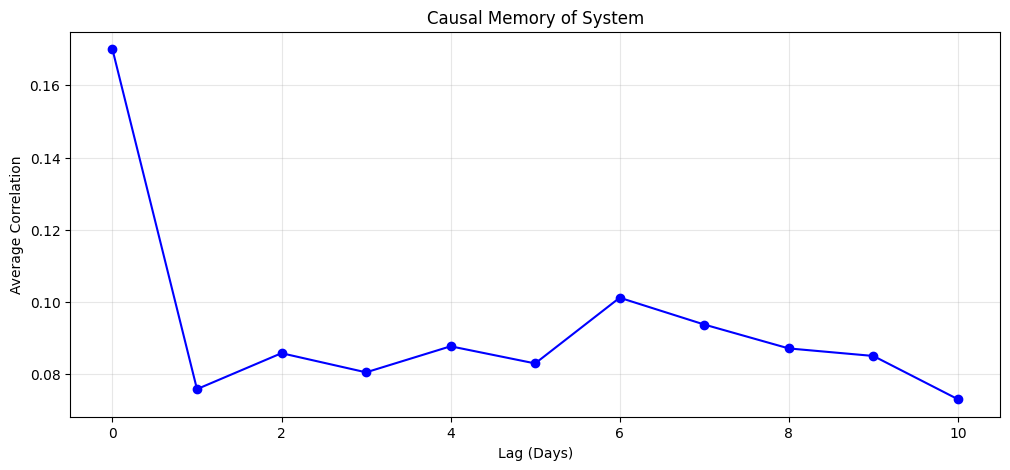

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

vals = df_transform.values
var_names = df_transform.columns.tolist()

# tigramite dataframe, mapping data to time indices for tau optimization later
dataframe = dp.DataFrame(vals, datatime=np.arange(len(vals)), var_names=var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

data_source = df_transform
vals = StandardScaler().fit_transform(data_source.values)
var_names = df_transform.columns.tolist()
T_num = len(vals)

dataframe = dp.DataFrame(vals, datatime=np.arange(T_num), var_names=var_names)
#initilize PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=dataframe, cond_ind_test=parcorr, verbosity=0)

#tau optimization up to tau=10
tau_results = pcmci.get_lagged_dependencies(tau_max=10, val_only=False)
val_matrix = tau_results['val_matrix']

#avg corrlation for each tau without self dependencies
avg_decays = []
n_vars = val_matrix.shape[0]
for tau in range(11):
    lag_matrix = np.abs(val_matrix[:, :, tau])
    np.fill_diagonal(lag_matrix, 0)
    avg_decays.append(np.sum(lag_matrix) / (n_vars * (n_vars - 1)))


plt.figure(figsize=(12, 5))
plt.title('Causal Memory of System')
plt.plot(range(11), avg_decays, marker='o', color='blue')
plt.xlabel('Lag (Days)')
plt.ylabel('Average Correlation')
#plt.axvline(x=#, color='red)
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
optimal_tau = 3

In [19]:
# optimizing alpha
alphas = [0.001, 0.01, 0.05, 0.1]
best_bic = float('inf')
best_alpha = None
results_dict = {}

for alpha in alphas:
    # RUN SPECIALIZED MODEL
    # tau_min=1 removes instant noise
    results = pcmci.run_pcmci(tau_min=1, tau_max=optimal_tau, pc_alpha=alpha)
    
    # calc BIC (Bayesian Information Criterion)
    graph = results['graph']
    n_edges = np.count_nonzero(graph != "")
    strength_sum = np.sum(np.abs(results['val_matrix'][graph != ""]))
    
    T_eff = T_num - optimal_tau
    
    # BIC: Penalty for Edges - Reward for Fit
    bic = (n_edges * np.log(T_eff)) - (2 * strength_sum * T_eff)
    
    results_dict[alpha] = results
    
    print(f"Alpha: {alpha:<5} | Edges: {n_edges:<3} | BIC: {bic:.0f}")
    
    if bic < best_bic:
        best_bic = bic
        best_alpha = alpha

print(f"Specialized Alpha: {best_alpha} (Lowest BIC)")

Alpha: 0.001 | Edges: 32  | BIC: -1409
Alpha: 0.01  | Edges: 31  | BIC: -1439
Alpha: 0.05  | Edges: 36  | BIC: -1742
Alpha: 0.1   | Edges: 36  | BIC: -1784
Specialized Alpha: 0.1 (Lowest BIC)


In [20]:


split_idx = int(len(vals) * 0.8)
train_vals = vals[:split_idx]
test_vals = vals[split_idx:]

# splitting training and testing based on time series data
train_df = dp.DataFrame(train_vals, datatime=np.arange(len(train_vals)), var_names = var_names)
test_df = dp.DataFrame(test_vals, datatime=np.arange(len(test_vals)), var_names = var_names)

parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_df, cond_ind_test=parcorr, verbosity=0)

baseline = pcmci.run_pcmci(tau_min=1, tau_max=5, pc_alpha=0.05)
specialized = pcmci.run_pcmci(tau_min=1, tau_max=2, pc_alpha=0.1)

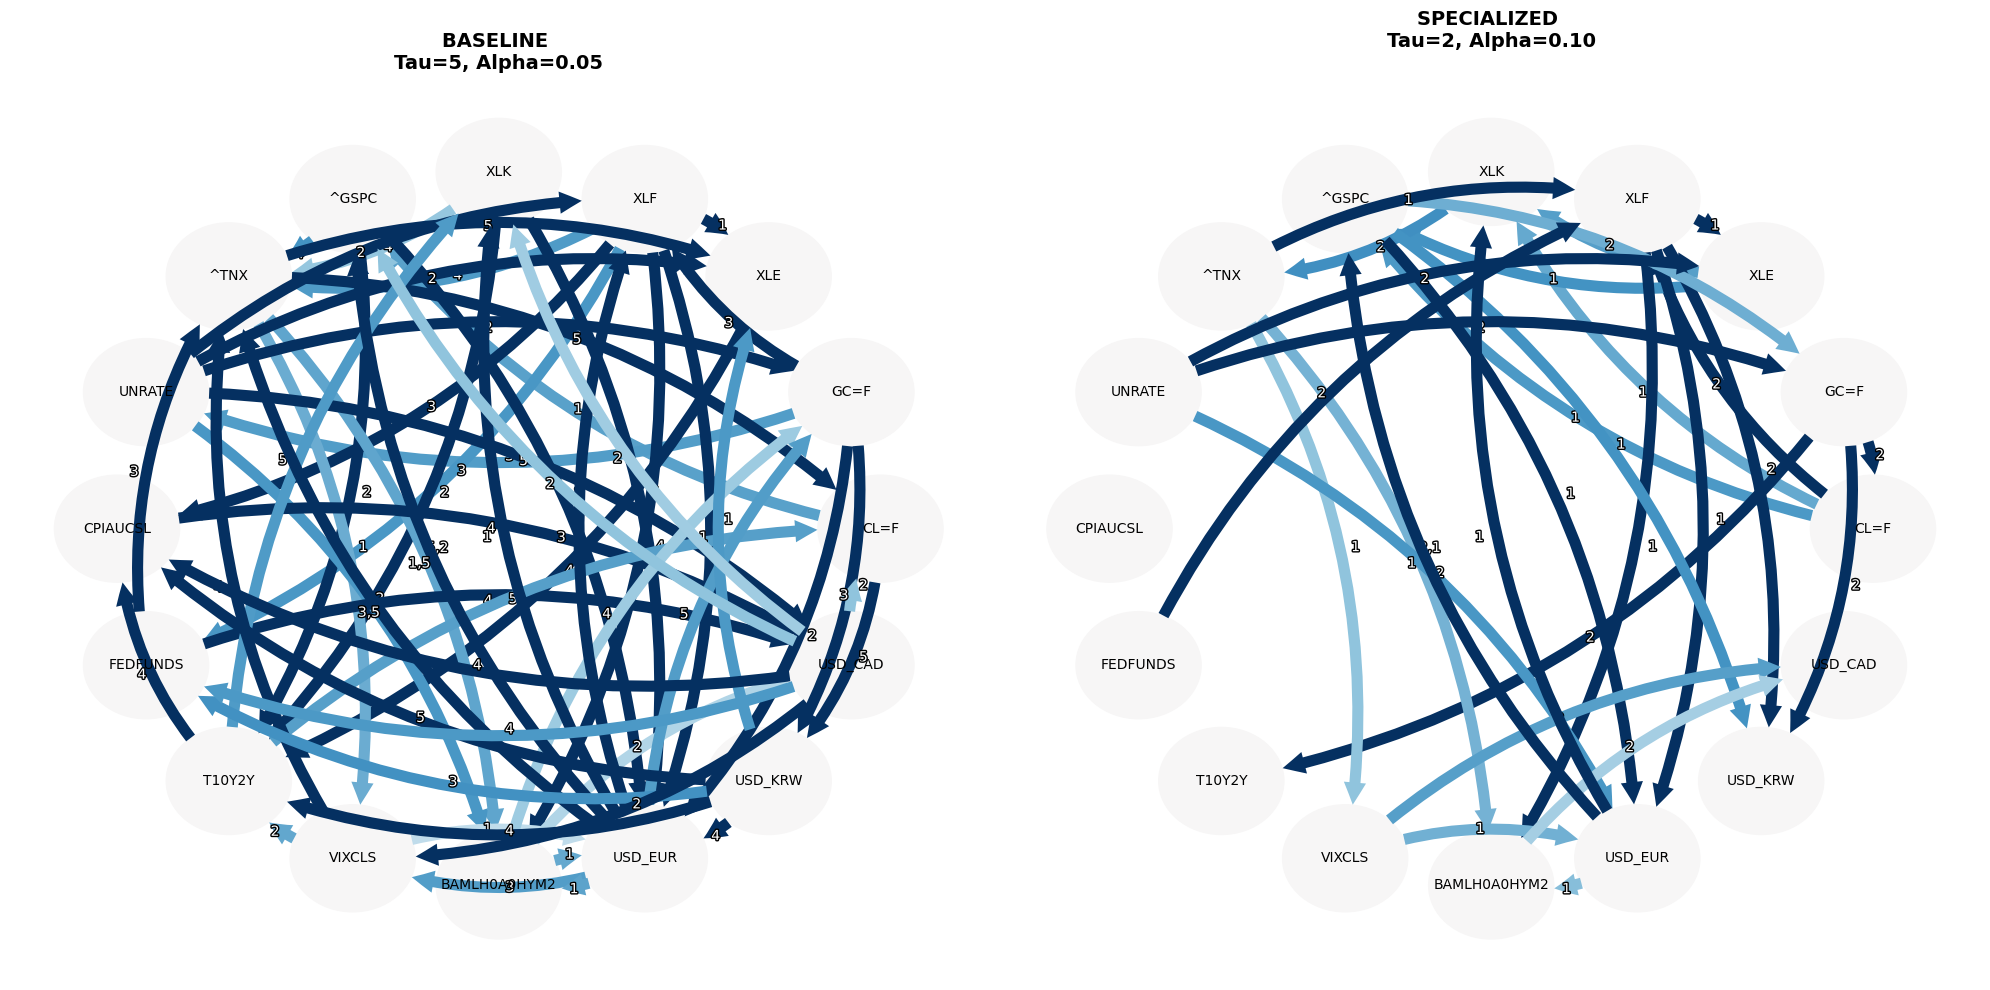

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# plot baseline
tp.plot_graph(
    val_matrix=baseline['val_matrix'],
    graph=baseline['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[0]) 
)
axes[0].set_title(f"BASELINE \nTau=5, Alpha=0.05", fontsize=14, fontweight='bold')

# Plot Specialized
tp.plot_graph(
    val_matrix=specialized['val_matrix'],
    graph=specialized['graph'],
    var_names=var_names,
    vmin_edges=0.05,
    show_colorbar=False,
    label_fontsize=10,
    fig_ax=(fig, axes[1])
)
axes[1].set_title(f"SPECIALIZED \nTau=2, Alpha=0.10\n", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


Training on 81 days, testing on 21 days

 Running Models 
1. Training Baseline
2. Training Specialized 

TARGET VARIABLE SELECTION
All Variables: ['CL=F', 'GC=F', 'XLE', 'XLF', 'XLK', '^GSPC', '^TNX', 'UNRATE', 'CPIAUCSL', 'FEDFUNDS', 'T10Y2Y', 'VIXCLS', 'BAMLH0A0HYM2', 'USD_EUR', 'USD_KRW', 'USD_CAD']

 TARGET: 'CL=F' (Index 0)
Predicting tomorrow's return for CL=F using past data

 Analyzing Causal Links 

 BASELINE SELECTION LOGIC:
   Criteria: P-Value < 0.05
   Found 3 relations passsing requirements
[('USD_CAD', 3, np.float64(0.33438290931587367), np.float64(0.005320161087161387), 15), ('^TNX', 5, np.float64(-0.30632840354202984), np.float64(0.009905687850972691), 6), ('T10Y2Y', 5, np.float64(0.2642082178210652), np.float64(0.028255120260108065), 10)]
 Using Top 3 Strongest for Regression:
   Variable             | Lag  | Strength   | P-Value (The Why)
   ------------------------------------------------------------
   USD_CAD              | 3    | 0.3344     | 0.00532        
   ^

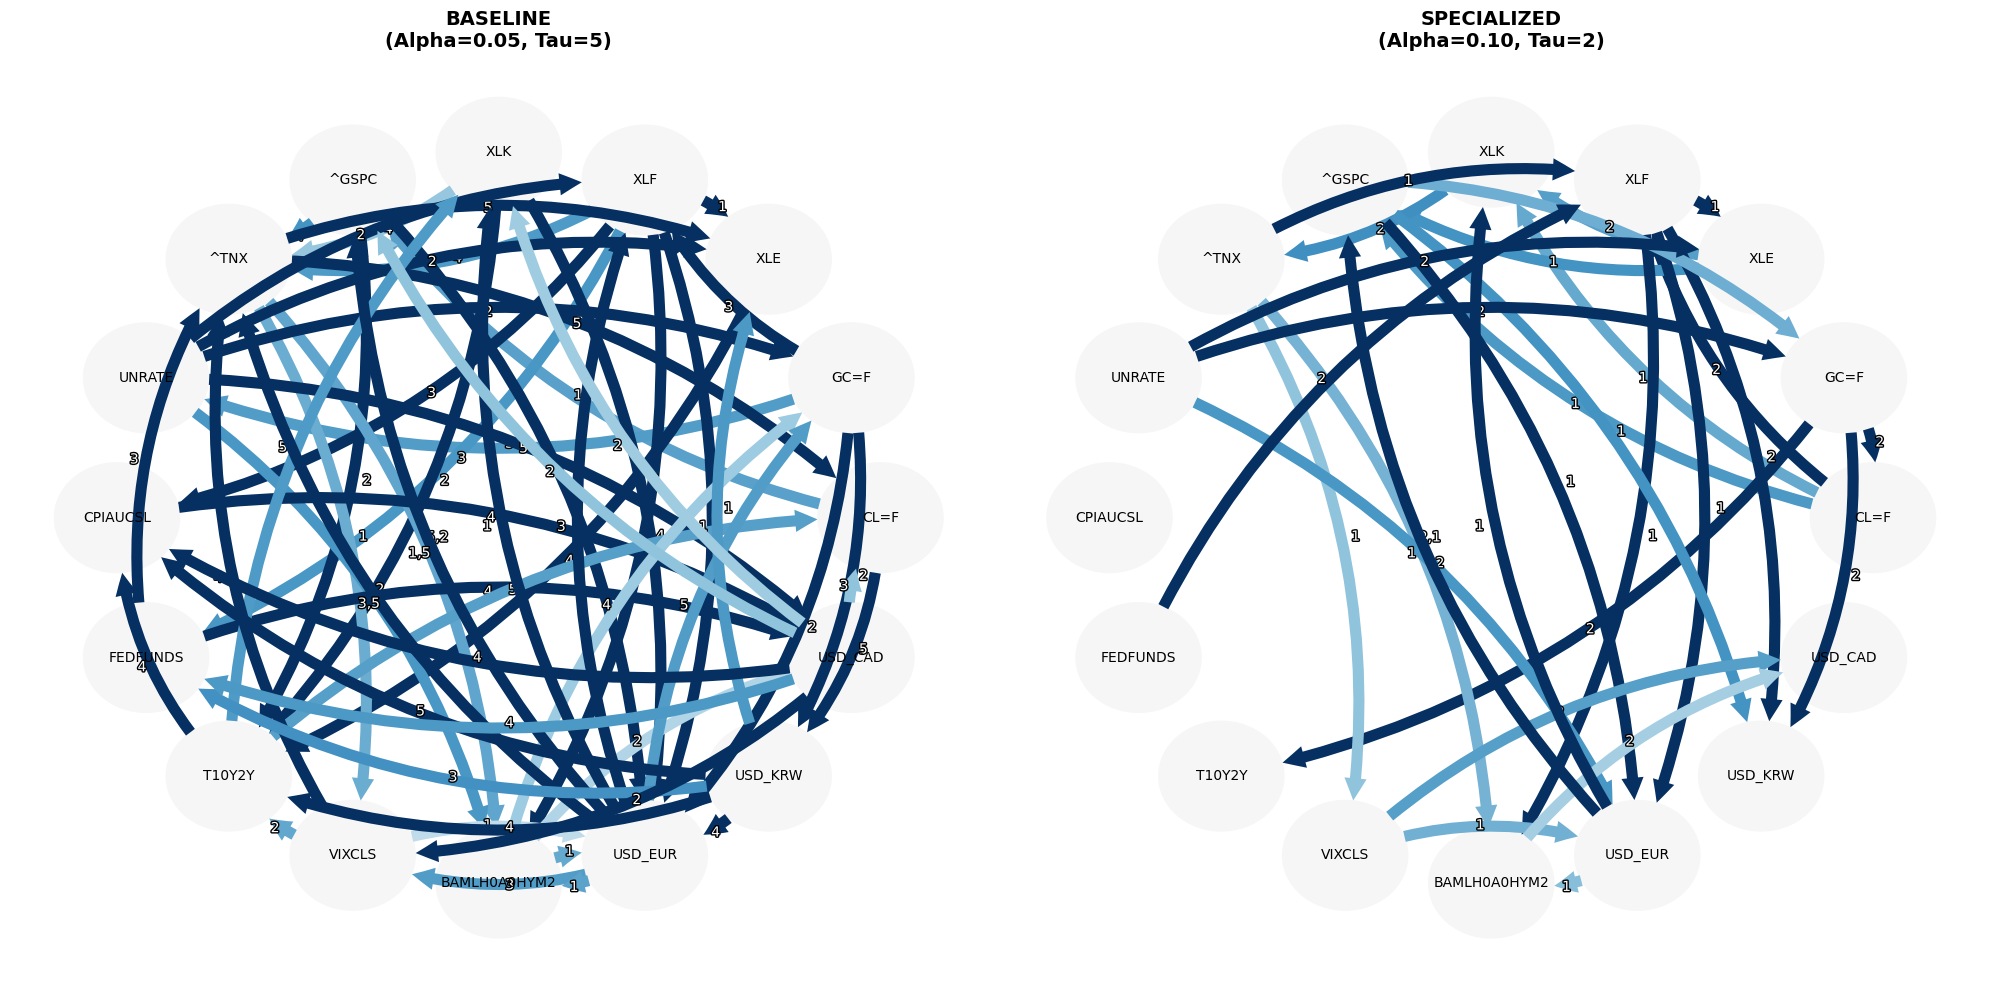

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from tigramite import data_processing as dp
from tigramite.pcmci import PCMCI
from tigramite.independence_tests.parcorr import ParCorr
from tigramite import plotting as tp

# DATA PREP & SPLITTING

data_source = df_transform

# Standardize
scaler = StandardScaler()
values_scaled = scaler.fit_transform(data_source.values)
var_names = data_source.columns.tolist()

# Chronological Split
split_idx = int(len(values_scaled) * 0.8)
train_values = values_scaled[:split_idx]
test_values = values_scaled[split_idx:]

# Tigramite Objects
train_dataframe = dp.DataFrame(train_values, datatime=np.arange(len(train_values)), var_names=var_names)
test_dataframe = dp.DataFrame(test_values, datatime=np.arange(len(test_values)), var_names=var_names)

# Initialize PCMCI
parcorr = ParCorr(significance='analytic')
pcmci = PCMCI(dataframe=train_dataframe, cond_ind_test=parcorr, verbosity=0)

print(f"Training on {len(train_values)} days, testing on {len(test_values)} days")




# RUNNING THE CAUSAL MODELS

TAU_NAIVE = 5      
TAU_OPTIMIZED = 2  

print("\n Running Models ")
print("1. Training Baseline")
res_baseline = pcmci.run_pcmci(tau_min=1, tau_max=TAU_NAIVE, pc_alpha=0.05)

print("2. Training Specialized ")
res_specialized = pcmci.run_pcmci(tau_min=1, tau_max=TAU_OPTIMIZED, pc_alpha=0.1)



# INSPECTION & CONTROL PANEL

# --- TARGET SELECTION ---
print("\n" + "="*50)
print("TARGET VARIABLE SELECTION")
print("="*50)
print(f"All Variables: {var_names}")

# Changing Target Variable
target_idx = 0 
target_name = var_names[target_idx]

print(f"\n TARGET: '{target_name}' (Index {target_idx})")
print(f"Predicting tomorrow's return for {target_name} using past data")


# --- CAUSAL SELECTION LOGIC ---
# CHOOSE HOW MANY PREDICTORS TO BE USED
MAX_PREDICTORS = 5 

def extract_and_filter_features(result, model_name, target_idx, alpha_threshold, limit=None):
    """
    finding data for linear regression
    """
    graph = result['graph']
    val_matrix = result['val_matrix']
    p_matrix = result['p_matrix'] # \(P-VALUES)
    
    parents = []
    
    # Scan for parents
    for var_j in range(len(var_names)):
        for lag in range(graph.shape[2]):
            if graph[var_j, target_idx, lag] != "":
                strength = val_matrix[var_j, target_idx, lag]
                p_value = p_matrix[var_j, target_idx, lag]
                parents.append((var_names[var_j], lag, strength, p_value, var_j))
    
    # sort by strength
    parents.sort(key=lambda x: abs(x[2]), reverse=True)
    
    print(f"\n {model_name} SELECTION LOGIC:")
    print(f"   Criteria: P-Value < {alpha_threshold}")
    print(f"   Found {len(parents)} relations passsing requirements")

    print(parents)
    
    # applying User Limit
    selected_parents = parents[:limit] if limit else parents
    
    # print Inspection Table
    print(f" Using Top {len(selected_parents)} Strongest for Regression:")
    print(f"   {'Variable':<20} | {'Lag':<4} | {'Strength':<10} | {'P-Value (The Why)':<15}")
    print("   " + "-"*60)
    
    for p in selected_parents:
        # p_value needs to be small
        p_str = f"{p[3]:.5f}" if p[3] > 0.0001 else "<0.0001 (Strong)"
        print(f"   {p[0]:<20} | {p[1]:<4} | {p[2]:.4f}     | {p_str:<15}")
        
    if not selected_parents:
        print("No parents found. Defaulting to Auto-Regression")
        selected_parents.append((target_name, 1, 1.0, 0.0, target_idx))
        
    return selected_parents

# Extract features
print("\n Analyzing Causal Links ")
feats_base = extract_and_filter_features(res_baseline, "BASELINE", target_idx, alpha_threshold=0.05, limit=MAX_PREDICTORS)
feats_spec = extract_and_filter_features(res_specialized, "SPECIALIZED", target_idx, alpha_threshold=0.10, limit=MAX_PREDICTORS)





# REGRESSION BENCHMARKING

def train_and_evaluate(train_data, test_data, features, target_idx, max_lag_global):
    def build_xy(data):
        y = data[max_lag_global:, target_idx]
        X_cols = []
        # feature list structure: (Name, Lag, Strength, P-Value, Index)
        for (_, lag, _, _, var_idx) in features:
            col = np.roll(data[:, var_idx], shift=lag)[max_lag_global:]
            X_cols.append(col)
        return np.column_stack(X_cols), y

    # ensuring alignment
    GLOBAL_CUTOFF = max(TAU_NAIVE, TAU_OPTIMIZED)
    
    X_train, y_train = build_xy(train_data)
    X_test, y_test   = build_xy(test_data)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))
    return mse

GLOBAL_CUTOFF = max(TAU_NAIVE, TAU_OPTIMIZED)
mse_base = train_and_evaluate(train_values, test_values, feats_base, target_idx, GLOBAL_CUTOFF)
mse_spec = train_and_evaluate(train_values, test_values, feats_spec, target_idx, GLOBAL_CUTOFF)

improvement = ((mse_base - mse_spec) / mse_base) * 100

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Target: {target_name}")
print(f"Baseline MSE:    {mse_base:.5f}")
print(f"Specialized MSE: {mse_spec:.5f}")

if improvement > 0:
    print(f"SUCCESS: {improvement:.2f}% Improvement")
else:
    print(f"Result: {improvement:.2f}%")






# VISUALIZATION

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

tp.plot_graph(
    val_matrix=res_baseline['val_matrix'], graph=res_baseline['graph'],
    var_names=var_names, vmin_edges=0.05, show_colorbar=False,
    label_fontsize=10, fig_ax=(fig, axes[0]) 
)
axes[0].set_title(f"BASELINE\n(Alpha=0.05, Tau=5)", fontsize=14, fontweight='bold')

tp.plot_graph(
    val_matrix=res_specialized['val_matrix'], graph=res_specialized['graph'],
    var_names=var_names, vmin_edges=0.05, show_colorbar=False,
    label_fontsize=10, fig_ax=(fig, axes[1])
)
axes[1].set_title(f"SPECIALIZED\n(Alpha=0.10, Tau=2)", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
graph = result['graph']
    val_matrix = result['val_matrix']
    p_matrix = result['p_matrix']

IndentationError: unexpected indent (4131816939.py, line 2)

In [ ]:
res_baseline['p_matrix']

In [ ]:
res_specialized